<a href="https://colab.research.google.com/github/padhab34-bit/IML/blob/main/Diabetes2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import requests

#URL for the diabetes dataset
dataset_url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

try:
    # Read the data, letting pandas infer the separator and using the first row as header
    df = pd.read_csv(dataset_url, sep='\t') # Assuming tab-separated based on .tab.txt

    print("New dataset loaded successfully!")
    display(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error downloading the dataset: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

New dataset loaded successfully!


,AGE,SEX,BMI,BP,...,S4,S5,S6,Y
0,59,2,32.1,101.0,...,4.0,4.8598,87,151
1,48,1,21.6,87.0,...,3.0,3.8918,69,75
2,72,2,30.5,93.0,...,4.0,4.6728,85,141
3,24,1,25.3,84.0,...,5.0,4.8903,89,206
4,50,1,23.0,101.0,...,4.0,4.2905,80,135


In [6]:
# Define features (X) and target (y) for consistency with the case study structure
# For the new dataset, 'Y' is the target variable and the other columns are features.
data = df.drop('Y', axis=1).values
target = df['Y'].values
feature_names = list(df.drop('Y', axis=1).columns)

# Displaying the shapes and feature names
print(f"Shape of data: {data.shape}")
print(f"Shape of target: {target.shape}")
print(f"Feature Names: {feature_names}")

Shape of data: (442, 10)
Shape of target: (442,)
Feature Names: ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6']


In [7]:
import pandas as pd

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 9)
pd.set_option('display.width', None)

# Create a DataFrame from the new data and add the 'Y' target
diabetes_df = pd.DataFrame(data, columns=feature_names)
diabetes_df['Y'] = pd.Series(target)

print("First 5 rows of the new Diabetes DataFrame:")
display(diabetes_df.head())

First 5 rows of the new Diabetes DataFrame:


,AGE,SEX,BMI,BP,...,S4,S5,S6,Y
0,59.0,2.0,32.1,101.0,...,4.0,4.8598,87.0,151
1,48.0,1.0,21.6,87.0,...,3.0,3.8918,69.0,75
2,72.0,2.0,30.5,93.0,...,4.0,4.6728,85.0,141
3,24.0,1.0,25.3,84.0,...,5.0,4.8903,89.0,206
4,50.0,1.0,23.0,101.0,...,4.0,4.2905,80.0,135


In [26]:
import pandas as pd

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 9)
pd.set_option('display.width', None)

# Create a DataFrame from the Pima data and add the 'outcome' target
pima_df = pd.DataFrame(pima_data, columns=pima_feature_names)
pima_df['outcome'] = pd.Series(pima_target)

print("First 5 rows of the Pima Indians Diabetes DataFrame:")
display(pima_df.head())

First 5 rows of the Pima Indians Diabetes DataFrame:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


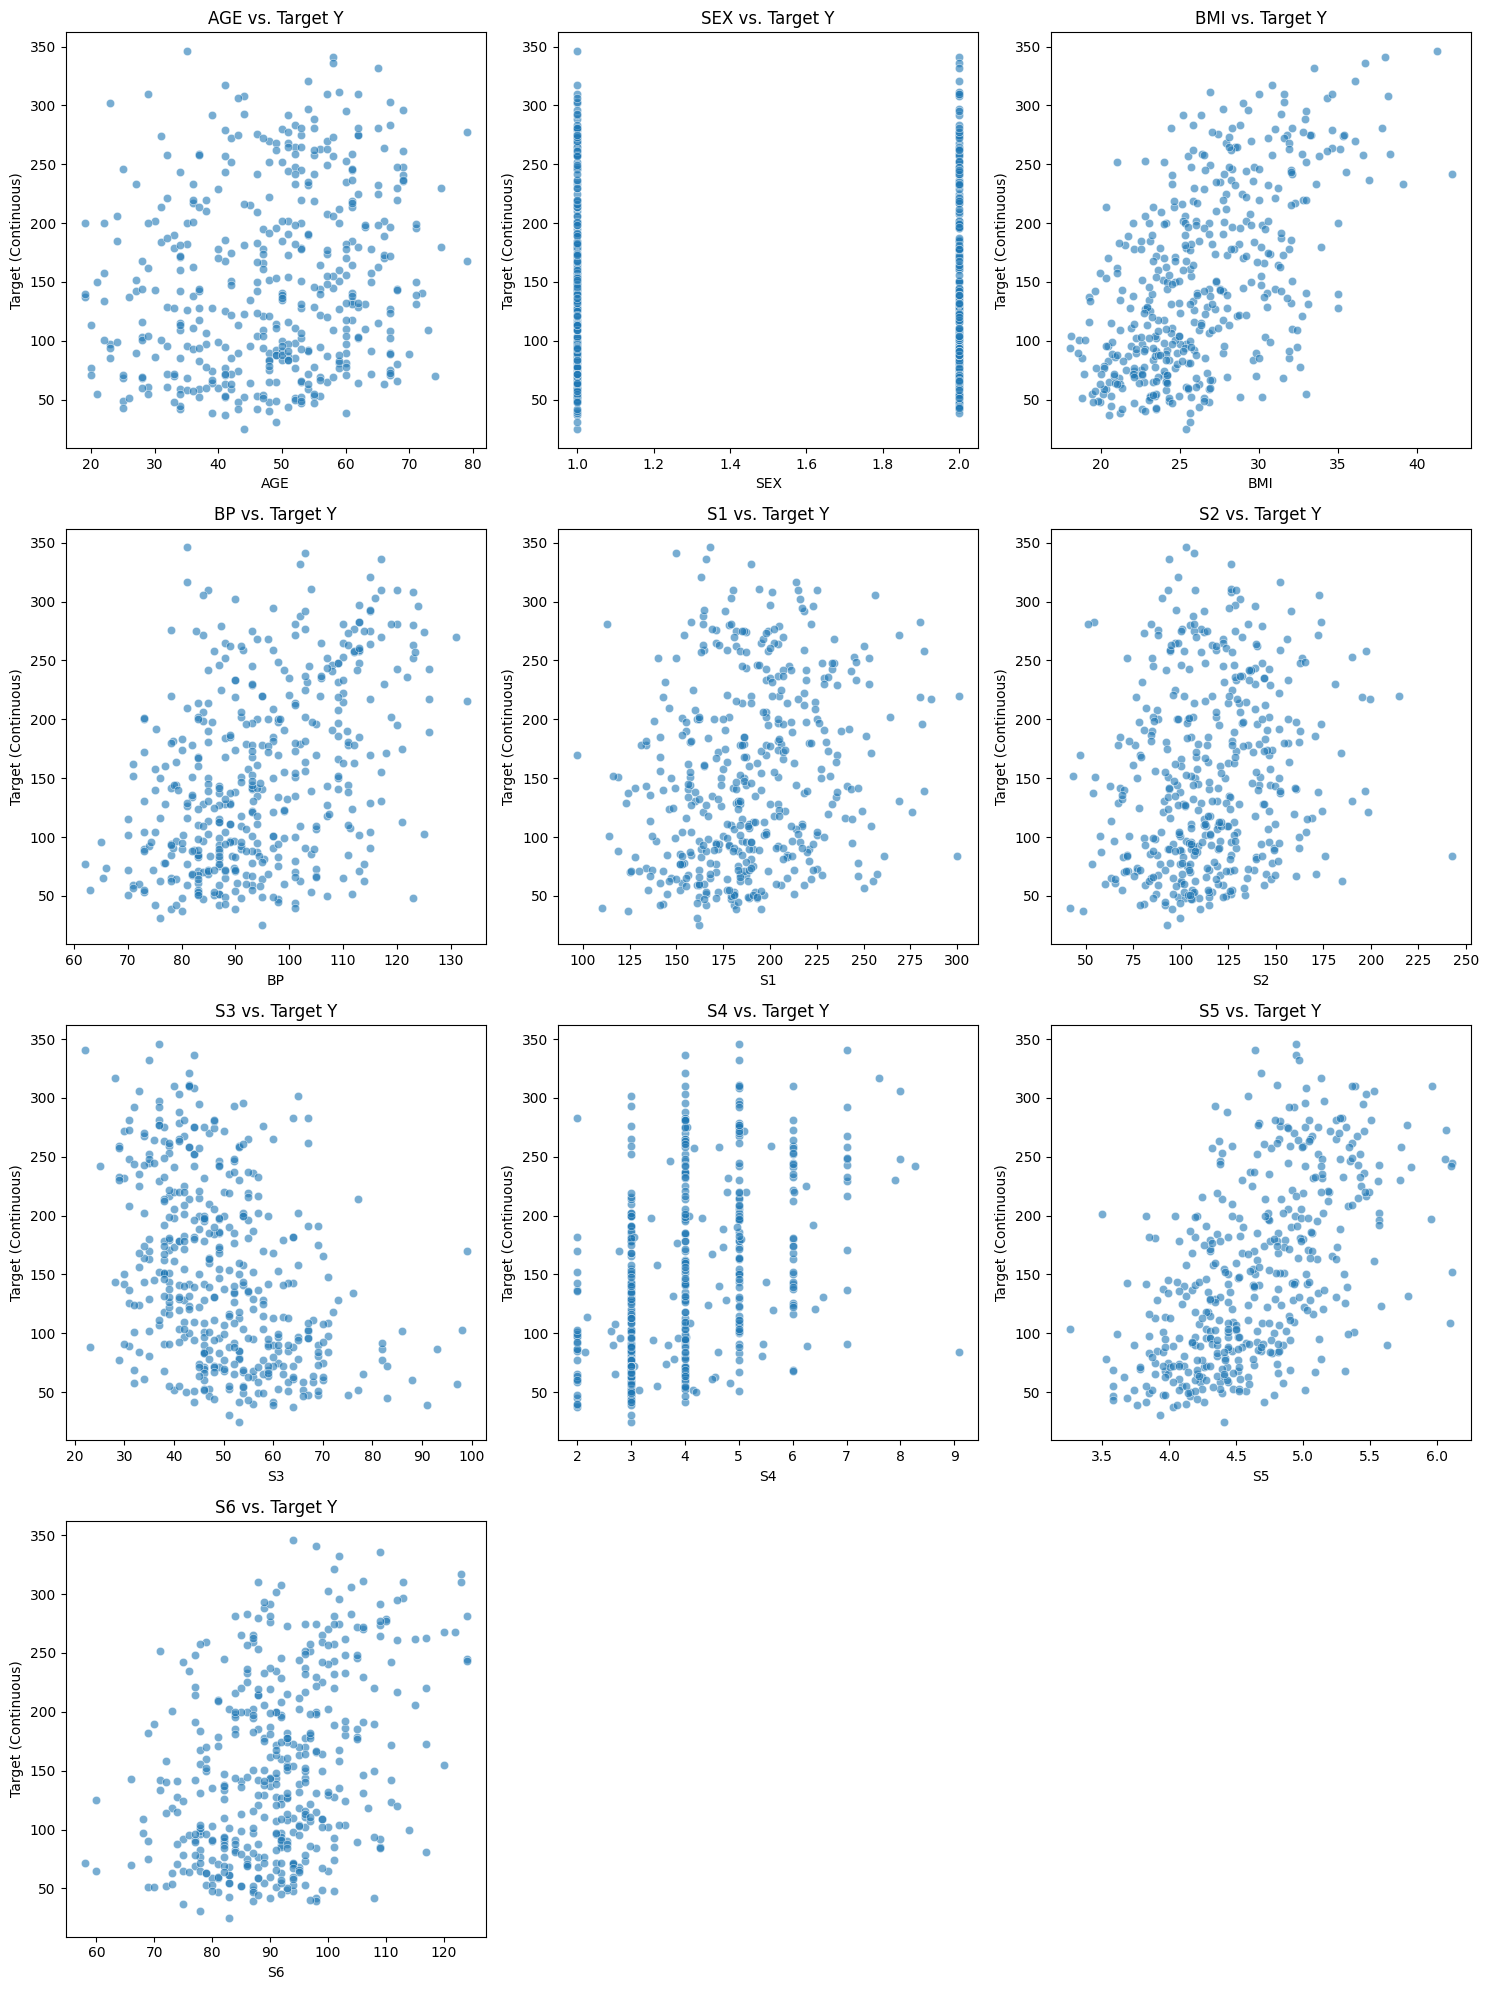

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better readability
plt.figure(figsize=(15, 20))

# Iterate through each feature and create a scatter plot against the target 'Y'
for i, feature in enumerate(feature_names):
    plt.subplot(4, 3, i + 1) # Arrange plots in 4 rows, 3 columns to accommodate 10 features
    sns.scatterplot(x=diabetes_df[feature], y=diabetes_df['Y'], alpha=0.6)
    plt.title(f'{feature} vs. Target Y')
    plt.xlabel(feature)
    plt.ylabel('Target (Continuous)')

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
# Removed 'stratify' as 'target' is a continuous variable, not categorical
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.20, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (353, 10)
Shape of X_test: (89, 10)
Shape of y_train: (353,)
Shape of y_test: (89,)


In [12]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X=X_train, y=y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [13]:
print("Coefficients:")
for i, name in enumerate(pima_feature_names):
    print(f'{name:>25}: {linear_regression.coef_[i]:.6f}')

print(f'\nIntercept: {linear_regression.intercept_:.6f}')

Coefficients:
              pregnancies: 0.137688
                  glucose: -23.064468
           blood_pressure: 5.846363
           skin_thickness: 1.197093
                  insulin: -1.281685
                      bmi: 0.811152
diabetes_pedigree_function: 0.601653
                      age: 10.159539

Intercept: -341.378236


In [14]:
predicted = linear_regression.predict(X_test)
expected = y_test

print("First five predicted values:")
display(predicted[:5])

print("\nFirst five expected (actual) values:")
display(expected[:5])

First five predicted values:


array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])


First five expected (actual) values:


array([219,  70, 202, 230, 111])

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for expected and predicted values
df_results = pd.DataFrame()
df_results['Expected'] = pd.Series(expected)
df_results['Predicted'] = pd.Series(predicted)

print("First 5 rows of the results DataFrame:")
display(df_results.head())

First 5 rows of the results DataFrame:


,Expected,Predicted
0,219,139.5476
1,70,179.5172
2,202,134.0388
3,230,291.4170
4,111,123.7897


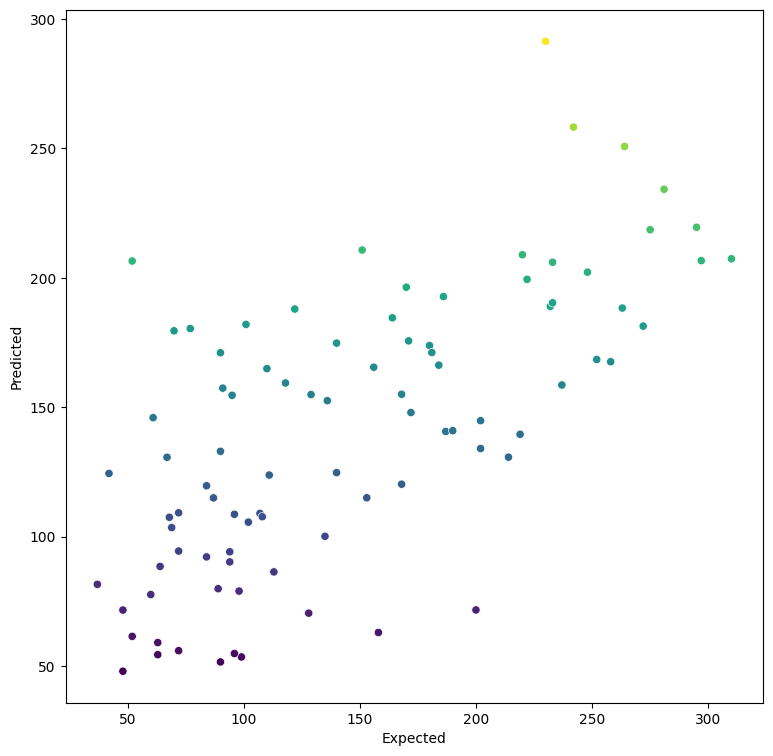

In [17]:
# Plot the data as a scatter plot
figure = plt.figure(figsize=(9, 9))
axes = sns.scatterplot(data=df_results, x='Expected', y='Predicted',
    hue='Predicted', palette='viridis', legend=False)

In [18]:
# Set x- and y-axes limits to use the same scale
start = min(df_results['Expected'].min(), df_results['Predicted'].min())
end = max(df_results['Expected'].max(), df_results['Predicted'].max())

axes.set_xlim(start, end)
axes.set_ylim(start, end)

(37.0, 310.0)

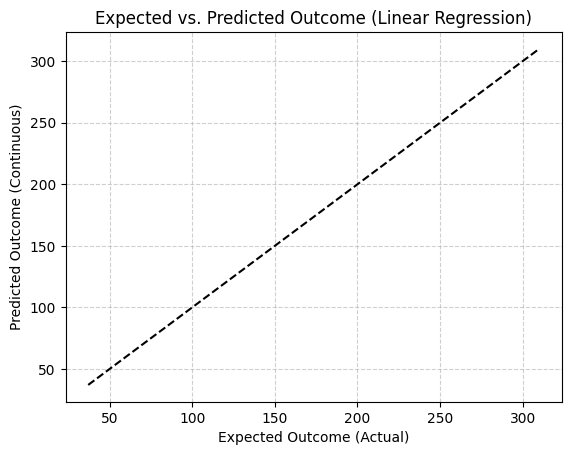

In [19]:
# Plot a line representing perfect predictions
line = plt.plot([start, end], [start, end], 'k--') # 'k--' for black dashed line

plt.title('Expected vs. Predicted Outcome (Linear Regression)')
plt.xlabel('Expected Outcome (Actual)')
plt.ylabel('Predicted Outcome (Continuous)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(expected, predicted)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(expected, predicted)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared
r_squared = r2_score(expected, predicted)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared: {r_squared:.4f}")

Mean Absolute Error (MAE): 42.7941
Mean Squared Error (MSE): 2900.1936
Root Mean Squared Error (RMSE): 53.8534
R-squared: 0.4526


In [21]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

estimators = {
    'LinearRegression': linear_regression, # Re-using the already trained linear_regression model
    'ElasticNet': ElasticNet(random_state=42), # Added random_state for reproducibility
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42)
}

In [24]:
from sklearn.model_selection import KFold, cross_val_score

for estimator_name, estimator_object in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator_object,
        X=data, y=target, cv=kfold,
        scoring='r2') # Using 'r2' score as specified
    print(f'{estimator_name:>16}: ' +
          f'mean of r2 scores={scores.mean():.3f}')

LinearRegression: mean of r2 scores=0.475
      ElasticNet: mean of r2 scores=0.452
           Lasso: mean of r2 scores=0.471
           Ridge: mean of r2 scores=0.475
